In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
 
import warnings
warnings.filterwarnings("ignore")
 
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

In [72]:
df = pd.read_csv("Mall_Customers.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
 
print("\nColumn info:")
print(df.info())
 
print("\nMissing values:")
print(df.isnull().sum())

Shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missi

In [73]:
df.columns = ["customer_id", "gender", "age", "annual_income", "spending_score"]
 
# Encode gender: Male=0, Female=1
df["gender_enc"] = df["gender"].map({"Male": 0, "Female": 1})
 
print("\nBasic stats:")
print(df.describe())


Basic stats:
       customer_id         age  annual_income  spending_score  gender_enc
count   200.000000  200.000000     200.000000      200.000000  200.000000
mean    100.500000   38.850000      60.560000       50.200000    0.560000
std      57.879185   13.969007      26.264721       25.823522    0.497633
min       1.000000   18.000000      15.000000        1.000000    0.000000
25%      50.750000   28.750000      41.500000       34.750000    0.000000
50%     100.500000   36.000000      61.500000       50.000000    1.000000
75%     150.250000   49.000000      78.000000       73.000000    1.000000
max     200.000000   70.000000     137.000000       99.000000    1.000000


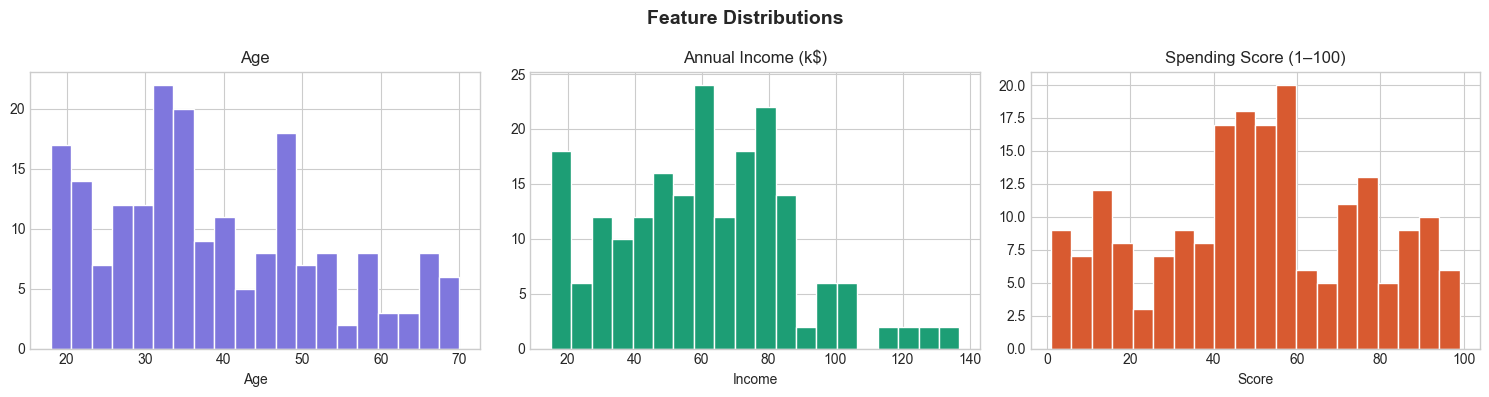

Saved: eda_distributions.png


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
 
axes[0].hist(df["age"], bins=20, color="#7F77DD", edgecolor="white")
axes[0].set_title("Age")
axes[0].set_xlabel("Age")
 
axes[1].hist(df["annual_income"], bins=20, color="#1D9E75", edgecolor="white")
axes[1].set_title("Annual Income (k$)")
axes[1].set_xlabel("Income")
 
axes[2].hist(df["spending_score"], bins=20, color="#D85A30", edgecolor="white")
axes[2].set_title("Spending Score (1–100)")
axes[2].set_xlabel("Score")
 
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_distributions.png")

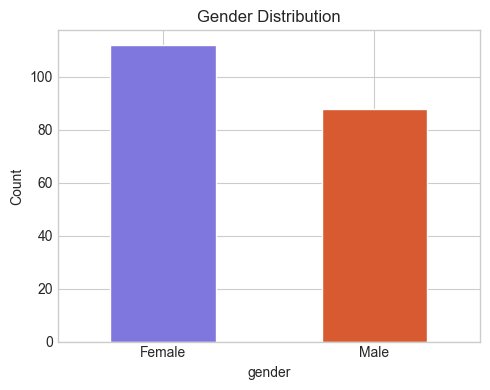

Saved: eda_gender.png


In [76]:
# Gender split
fig, ax = plt.subplots(figsize=(5, 4))
df["gender"].value_counts().plot(kind="bar", ax=ax, color=["#7F77DD", "#D85A30"],
                                  edgecolor="white", rot=0)
ax.set_title("Gender Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("eda_gender.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_gender.png")

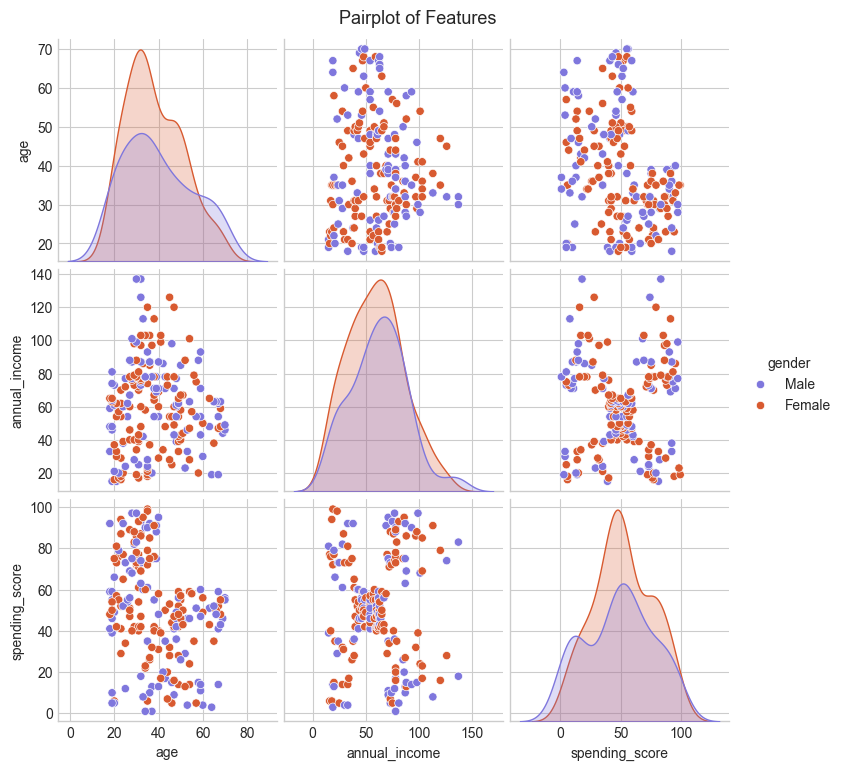

Saved: eda_pairplot.png


In [77]:
# Pairplot of key features
sns.pairplot(df[["age", "annual_income", "spending_score", "gender"]],
             hue="gender", palette={"Male": "#7F77DD", "Female": "#D85A30"})
plt.suptitle("Pairplot of Features", y=1.02, fontsize=13)
plt.savefig("eda_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_pairplot.png")

In [79]:
# Feature Selection & Scaling
# Using income + spending score (the classic 2D view)
# To use all features: change features list below
features = ["annual_income", "spending_score"]
# features = ["age", "annual_income", "spending_score", "gender_enc"]  # full features
X = df[features].values
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
print(f"\nUsing features: {features}")
print(f"Scaled data shape: {X_scaled.shape}")


Using features: ['annual_income', 'spending_score']
Scaled data shape: (200, 2)


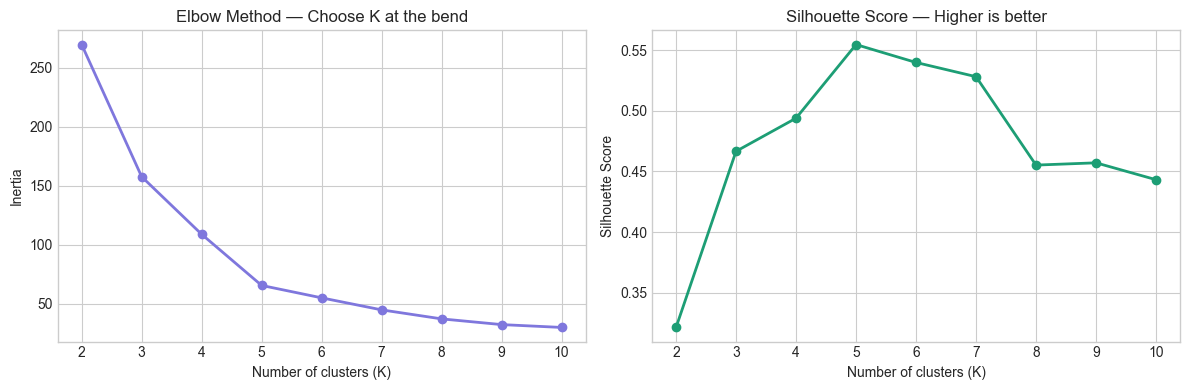

Saved: elbow_silhouette.png

Best K by silhouette score: 5
Review the elbow plot and choose your K (default set to 5 below)


In [80]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)
 
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10,
                random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
ax1.plot(list(K_range), inertias, marker="o", color="#7F77DD", linewidth=2)
ax1.set_title("Elbow Method — Choose K at the bend")
ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("Inertia")
 
ax2.plot(list(K_range), silhouette_scores, marker="o", color="#1D9E75", linewidth=2)
ax2.set_title("Silhouette Score — Higher is better")
ax2.set_xlabel("Number of clusters (K)")
ax2.set_ylabel("Silhouette Score")
 
plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: elbow_silhouette.png")
 
best_k_sil = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K by silhouette score: {best_k_sil}")
print("Review the elbow plot and choose your K (default set to 5 below)")

In [81]:
K = best_k_sil

kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
kmeans.fit(X_scaled)
 
df["cluster"] = kmeans.labels_
print(f"\nCluster distribution (K={K}):")
print(df["cluster"].value_counts().sort_index())


Cluster distribution (K=5):
cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


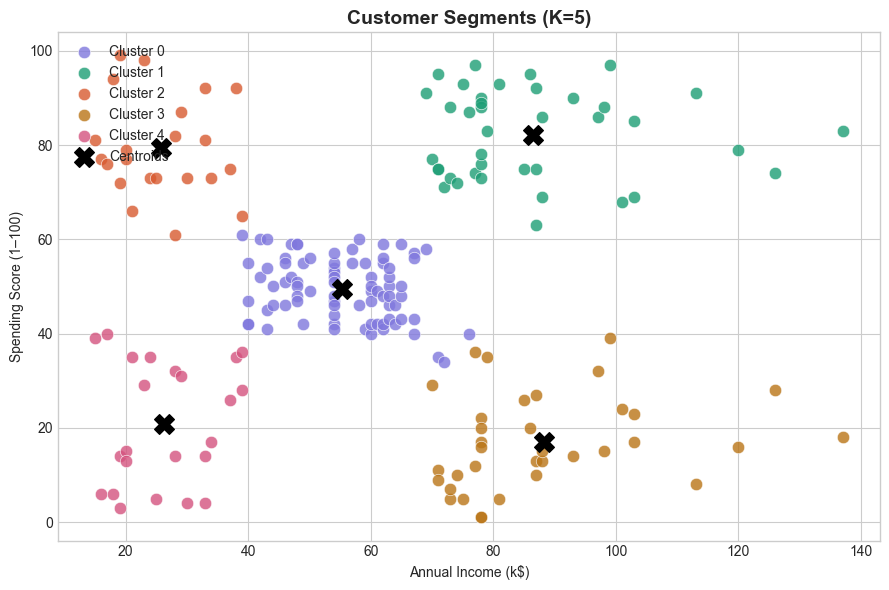

Saved: clusters_2d.png


In [83]:
# Visualize Clusters
palette = ["#7F77DD", "#1D9E75", "#D85A30", "#BA7517", "#D4537E"]
 
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K):
    mask = df["cluster"] == c
    ax.scatter(df.loc[mask, "annual_income"],
               df.loc[mask, "spending_score"],
               label=f"Cluster {c}",
               color=palette[c], s=80, alpha=0.8, edgecolors="white", linewidth=0.5)
 
# Plot centroids (inverse transform back to original scale)
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centers_orig[:, 0], centers_orig[:, 1],
           marker="X", s=200, c="black", zorder=5, label="Centroids")
 
ax.set_title(f"Customer Segments (K={K})", fontsize=14, fontweight="bold")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1–100)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("clusters_2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: clusters_2d.png")


── Cluster Profiles ──────────────────────────────────
          age  annual_income  spending_score  count  gender_female_%
cluster                                                             
0        42.7           55.3            49.5     81             59.3
1        32.7           86.5            82.1     39             53.8
2        25.3           25.7            79.4     22             59.1
3        41.1           88.2            17.1     35             45.7
4        45.2           26.3            20.9     23             60.9


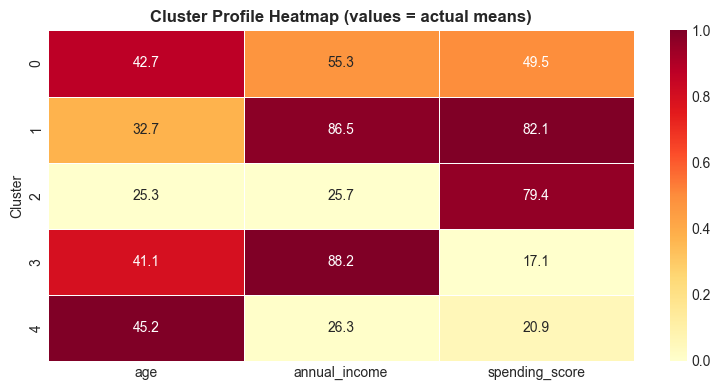

Saved: cluster_heatmap.png


In [84]:
# Cluster Profiling

profile_cols = ["age", "annual_income", "spending_score"]
profile = df.groupby("cluster")[profile_cols].mean().round(1)
profile["count"] = df["cluster"].value_counts().sort_index()
profile["gender_female_%"] = (
    df.groupby("cluster")["gender_enc"].mean() * 100
).round(1)
 
print("\n── Cluster Profiles ──────────────────────────────────")
print(profile.to_string())
 
# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(8, 4))
normalized = (profile[profile_cols] - profile[profile_cols].min()) / \
             (profile[profile_cols].max() - profile[profile_cols].min())
sns.heatmap(normalized, annot=profile[profile_cols], fmt=".1f",
            cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Cluster Profile Heatmap (values = actual means)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_heatmap.png")

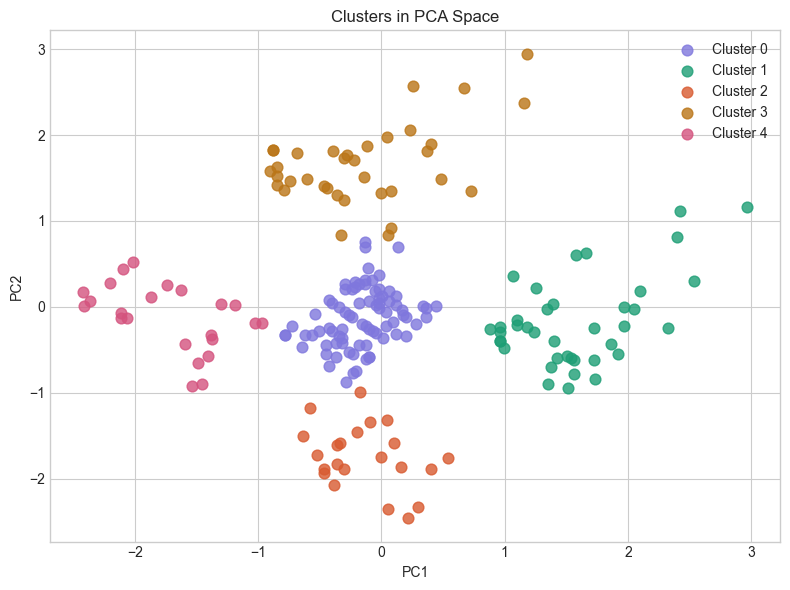

In [86]:
# (Optional) PCA for 3-feature+ visualisation
# Uncomment this block if you used more than 2 features above
 
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(K):
    mask = df["cluster"] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f"Cluster {c}", color=palette[c], s=60, alpha=0.8)
ax.set_title("Clusters in PCA Space")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(); plt.tight_layout()
plt.savefig("clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [87]:
# Save Results
df.to_csv("customers_with_clusters.csv", index=False)
print("\nSaved: customers_with_clusters.csv")
 
print("\n✓ Pipeline complete!")
print(f"  Model: KMeans | K={K} | Features: {features}")
print(f"  Final silhouette score: {silhouette_score(X_scaled, kmeans.labels_):.4f}")


Saved: customers_with_clusters.csv

✓ Pipeline complete!
  Model: KMeans | K=5 | Features: ['annual_income', 'spending_score']
  Final silhouette score: 0.5547
